In [1]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (18, 5)  # To make all charts in notebook same size default
import seaborn as sns
from datetime import date
pd.set_option('display.max_columns', None) # display all columns without ...

In [2]:
# Fetching data into dataframe df and making column zero as index column

df = pd.read_csv("india_housing_prices.csv",index_col=0) 

In [3]:
# To Know number of columns and rows in the dataframe

df.shape  

(250000, 22)

In [4]:
df.head()  # To fetch top 5 rows of the dataframe

,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
ID,,,,,,,,,,,,,,,,,,,,,,
1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,Furnished,22,1,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,Unfurnished,21,20,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,Semi-furnished,19,27,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,Furnished,21,26,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,Semi-furnished,3,2,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [5]:
# To check the dataypes, count of non-null values and column names

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250000 entries, 1 to 250000
Data columns (total 22 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   State                           250000 non-null  object 
 1   City                            250000 non-null  object 
 2   Locality                        250000 non-null  object 
 3   Property_Type                   250000 non-null  object 
 4   BHK                             250000 non-null  int64  
 5   Size_in_SqFt                    250000 non-null  int64  
 6   Price_in_Lakhs                  250000 non-null  float64
 7   Price_per_SqFt                  250000 non-null  float64
 8   Year_Built                      250000 non-null  int64  
 9   Furnished_Status                250000 non-null  object 
 10  Floor_No                        250000 non-null  int64  
 11  Total_Floors                    250000 non-null  int64  
 12  Age_of_Property      

In [6]:
# To get statistical summary of numeric variables in df

df.describe()

,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,2.999396,2749.813216,254.586854,0.130597,2006.520012,14.966800,15.503004,18.479988,5.499860,5.498016
std,1.415521,1300.606954,141.349921,0.130747,9.808575,8.948047,8.671618,9.808575,2.878639,2.871860
min,1.000000,500.000000,10.000000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,2.000000,1623.000000,132.550000,0.050000,1998.000000,7.000000,8.000000,10.000000,3.000000,3.000000
50%,3.000000,2747.000000,253.870000,0.090000,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,4.000000,3874.000000,376.880000,0.160000,2015.000000,23.000000,23.000000,27.000000,8.000000,8.000000
max,5.000000,5000.000000,500.000000,0.990000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


# Data preprocessing

## 1. Duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

## 2. Null values

In [8]:
df.isnull().sum()

State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64

## 3. Dropping rows

In [9]:
df[df["Floor_No"] > df["Total_Floors"]]

,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
ID,,,,,,,,,,,,,,,,,,,,,,
1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,Furnished,22,1,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,Unfurnished,21,20,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,Semi-furnished,3,2,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move
6,West Bengal,Durgapur,Locality_246,Apartment,4,3500,135.28,0.04,2020,Semi-furnished,27,1,5,7,7,Low,Yes,Yes,"Playground, Clubhouse",West,Broker,Ready_to_Move
7,Tamil Nadu,Coimbatore,Locality_254,Independent House,3,4826,318.12,0.07,2016,Furnished,16,5,9,3,6,High,No,Yes,"Clubhouse, Garden, Playground",North,Builder,Under_Construction
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249990,Delhi,Dwarka,Locality_208,Villa,1,4802,245.29,0.05,1992,Unfurnished,26,10,33,8,5,Low,No,Yes,"Gym, Pool, Garden",North,Broker,Ready_to_Move
249991,Jharkhand,Ranchi,Locality_403,Villa,3,1261,307.44,0.24,2019,Semi-furnished,21,13,6,10,9,Medium,Yes,No,"Clubhouse, Playground",East,Owner,Under_Construction
249993,Delhi,Dwarka,Locality_83,Apartment,1,3408,225.27,0.07,2003,Furnished,20,15,22,9,4,Low,Yes,Yes,"Pool, Playground, Gym, Garden, Clubhouse",East,Builder,Ready_to_Move


In [10]:
# Replacing values where Floor_no > Total_floors with property_type independent house and villa to 1 (Floor_no = 1 , Total_floors =1 )

mask = (
    (df["Floor_No"] > df["Total_Floors"]) &
    (df["Property_Type"].isin(["Independent House", "Villa"]))
)

df.loc[mask, ["Floor_No", "Total_Floors"]] = 1

In [11]:
# Dropping rows where Floor_no > Total_floors 

df = df.drop(df[df["Floor_No"] > df["Total_Floors"]].index)

In [12]:
df.shape

(211361, 22)

## 3. Adding new columns (Feature Engineering)
##### Amenities dummies columns,amenities_count,Age_of_Property,Local_avg_price, Undervalued,Age_score, Livability_score, Investment_score ,Appreciation_rate

In [13]:
## Dropping Price_in_lakhs and adding Price_in_Rs column for easy calculation and understanding

df["Price_in_Rs"] = df["Price_in_Lakhs"]*100000

del df["Price_in_Lakhs"]   ## Dropping the Price_in_Lakhs column

## Modifying existing columns with new calculation

df["Price_per_SqFt"] = (df["Price_in_Rs"]/df["Size_in_SqFt"]).astype(int)

current_year = date.today().year  ## getting current date

df["Age_of_Property"] = current_year - df["Year_Built"]

In [14]:
amenities_dummies = df['Amenities'].str.get_dummies(sep=', ')
df = pd.concat([df, amenities_dummies], axis=1)

In [15]:
amenities_dummies.sum().sort_values(ascending=False)

Garden        126844
Pool          126836
Clubhouse     126780
Gym           126747
Playground    126642
dtype: int64

In [16]:
df['amenities_count'] = amenities_dummies.sum(axis=1)

In [17]:
df['local_avg_price'] = df.groupby(['City', 'Locality'])['Price_per_SqFt'].transform('median')
df['undervalued'] = df['Price_per_SqFt'] < df['local_avg_price'] 
 

## Location Quality Score

df['location_score'] = (df['Nearby_Schools'] + df['Nearby_Hospitals'] + df['Public_Transport_Accessibility'].map({'High': 2, 'Medium': 1,'Low':0}))
        
## Property Condition
        
df['age_score'] = df['Age_of_Property'].apply(lambda x: 3 if x <=5 else (2 if x<=15 else 1))
        
       
## Livability / Rental Appeal

df['livability_score'] = (df['amenities_count'] 
                          + df['Parking_Space'].str.strip().str.lower().map({'yes': 1, 'no': 0})
                          + df['Security'].str.strip().str.lower().map({'yes': 1, 'no': 0}))

## Final Investment Score

df['investment_score'] = ((df['undervalued'].astype(int) * 3) +   # strong weight
                          (df['location_score'] * 2) +
                          (df['age_score'] * 2) +
                          df['livability_score'])


        
good_props = df[df['investment_score'] > df['investment_score'].quantile(0.75)]


In [18]:
df = df.sort_values(['City', 'Locality', 'Year_Built'])

In [19]:
df['appreciation_rate'] = (
    df.groupby(['City', 'Locality'])['Price_per_SqFt']
      .pct_change()*100
)

In [20]:
threshold = 0.10
high_growth = df[df['appreciation_rate'] > threshold]

In [21]:
df.to_csv("cleaned_new.csv", index=False)

In [22]:
# To see min and max values of the numeric columns

df.describe().loc[['min', 'max','mean']]

,BHK,Size_in_SqFt,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Price_in_Rs,Clubhouse,Garden,Gym,Playground,Pool,amenities_count,local_avg_price,location_score,age_score,livability_score,investment_score,appreciation_rate
min,1.000000,500.000000,202.000000,1990.000000,0.000000,1.000000,3.000000,1.000000,1.000000,1.000000e+06,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,782.000000,2.000000,1.000000,1.000000,7.000000,-99.669834
max,5.000000,5000.000000,99182.000000,2023.000000,30.000000,30.000000,36.000000,10.000000,10.000000,5.000000e+07,1.000000,1.00000,1.000000,1.000000,1.000000,5.000000,50173.000000,22.000000,3.000000,7.000000,60.000000,35463.485477
mean,2.997989,2749.930758,13073.506375,2006.520782,6.711498,13.047965,19.479218,5.497679,5.501937,2.547097e+07,0.599827,0.60013,0.599671,0.599174,0.600092,2.998893,9634.226087,12.002063,1.471918,3.998259,32.372065,183.995916


In [23]:
# To see the unique and top values in categorical columns of df

df.describe(include = object).loc[['unique','top']]

,State,City,Locality,Property_Type,Furnished_Status,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
unique,20,42,500,3,3,3,2,2,325,4,3,2
top,Tamil Nadu,Coimbatore,Locality_296,Villa,Unfurnished,High,No,Yes,Pool,West,Broker,Under_Construction


In [24]:
# Physical Impossibility: A unit cannot exist on a floor higher than the building's total height (e.g., Floor 25 in a 3-story building).
# Property Mismatch: Villas and Independent Houses are low-rise structures; high floor numbers are only logically valid for Apartments
# Data Corruption: These rows represent "dirty data" or entry errors that will skew averages and must be filtered out for accurate analysis.

## Exploratory Data Analysis (EDA)
### 1–5: Price & Size Analysis

## 1.	What is the distribution of property prices?

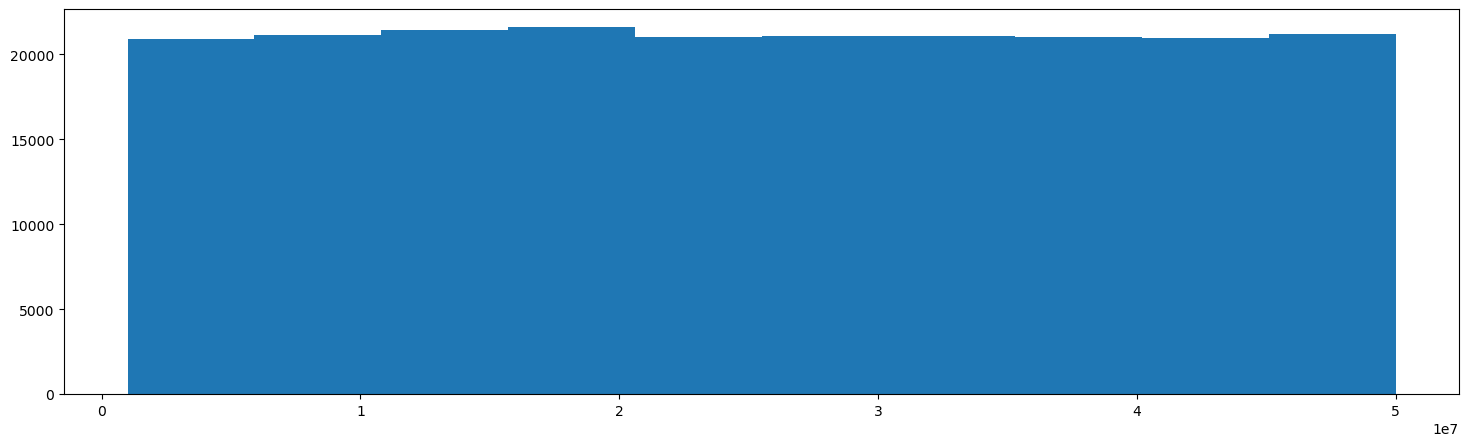

In [25]:
plt.hist(df["Price_in_Rs"])
plt.show()

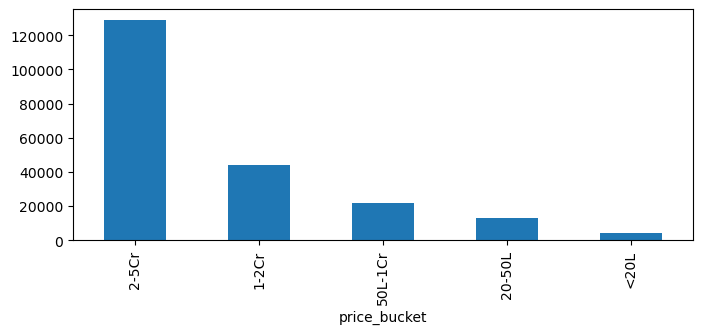

In [26]:
bins = [0, 2e6, 5e6, 1e7, 2e7, 5e7]
labels = ["<20L", "20-50L", "50L-1Cr", "1-2Cr", "2-5Cr"]
plt.figure(figsize = (8,3))
df["price_bucket"] = pd.cut(df["Price_in_Rs"], bins=bins, labels=labels,right = False)

df["price_bucket"].value_counts().plot(kind="bar")
plt.show()

In [27]:
df["price_bucket"].value_counts()

price_bucket
2-5Cr      128956
1-2Cr       43846
50L-1Cr     21530
20-50L      12807
<20L         4221
Name: count, dtype: int64

We can see the distribution as uniform distribution but with 48,313 unique values out of ~2.1M rows, data is not synthetic uniform data. Instead, it’s likely:
Highly repeated + fairly evenly spread across the range
Majority in ₹2Cr – ₹5Cr range 
Drop after ₹1Cr - ₹2Cr range  
Very small % in <₹20L

## 2.	What is the distribution of property sizes?

<Axes: xlabel='Size_in_SqFt', ylabel='Density'>

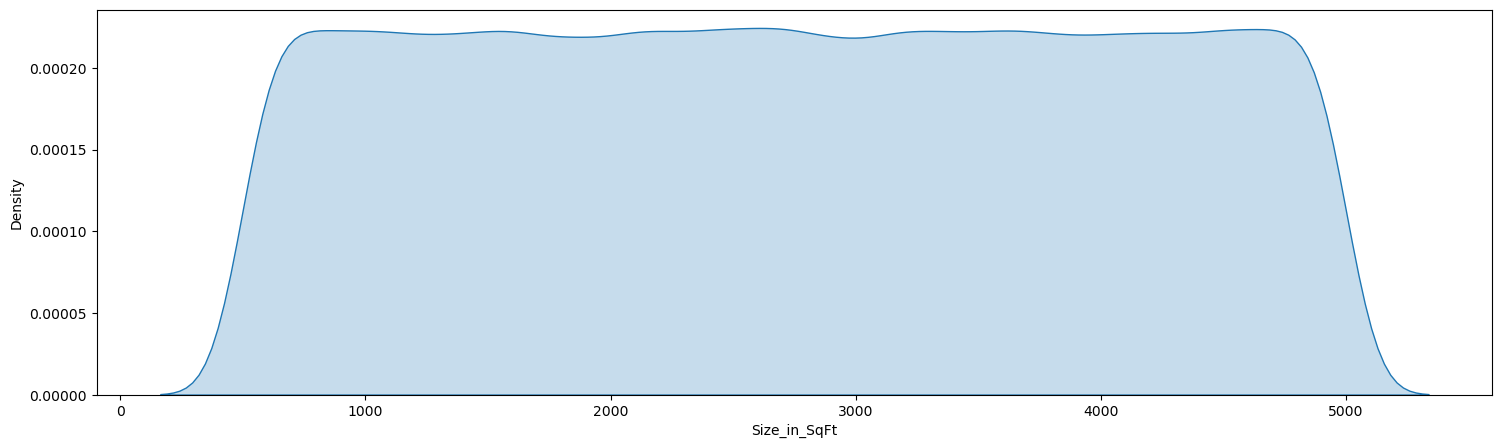

In [28]:
sns.kdeplot(df["Size_in_SqFt"],fill = True)

In [29]:
bins = [0, 1000, 2000, 3000, 4000, 5000]
labels = ["<1K", "1K-2K", "2K-3K", "3K-4K", "4K-5K"]

df["size_bucket"] = pd.cut(df["Size_in_SqFt"], bins=bins, labels=labels)

In [30]:
df["size_bucket"].value_counts()

size_bucket
2K-3K    47090
4K-5K    47090
3K-4K    46785
1K-2K    46675
<1K      23721
Name: count, dtype: int64

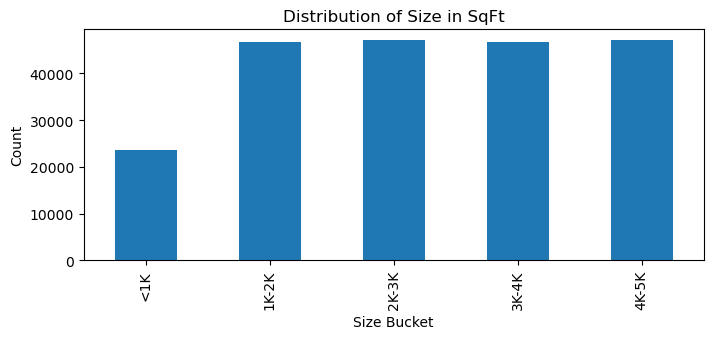

In [31]:
plt.figure(figsize=(8,3))
df["size_bucket"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Size Bucket")
plt.ylabel("Count")
plt.title("Distribution of Size in SqFt")
plt.show()

The size distribution is essentially uniform between ~500 and 5000 sqft, with each bucket having nearly equal counts—no dominant size range.The smooth KDE and flat bar chart confirm the data is evenly (likely synthetically) distributed, not reflecting real-world housing patterns
The counts are nearly uniform across 1K–5K sqft buckets, with only the <1K range lower due to the truncated starting bound at 500 sqft

## 3.	How does price per sq ft vary by property type?

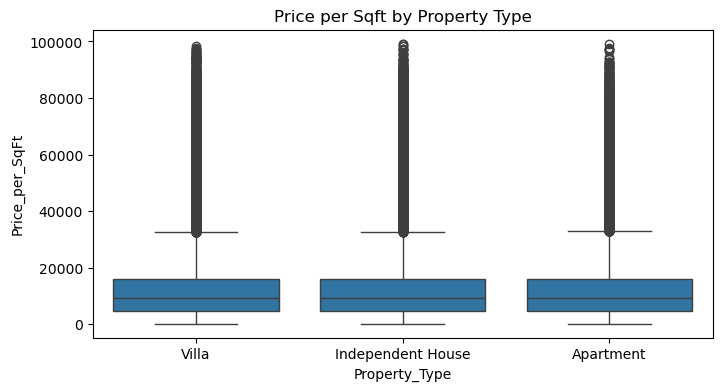

In [32]:
plt.figure(figsize=(8,4))
sns.boxplot(x="Property_Type", y="Price_per_SqFt", data=df)
plt.title("Price per Sqft by Property Type")
plt.show()

In [33]:
df.groupby('Property_Type')['Price_per_SqFt'].mean()

Property_Type
Apartment            13112.252973
Independent House    13101.549016
Villa                13025.107864
Name: Price_per_SqFt, dtype: float64

## 4.	Is there a relationship between property size and price?

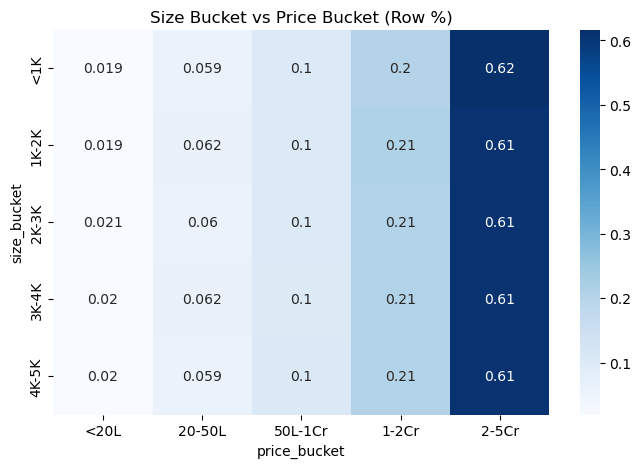

In [34]:
plt.figure(figsize=(8,5))
ct = pd.crosstab(df["size_bucket"], df["price_bucket"], normalize="index")
sns.heatmap(ct, annot=True, cmap="Blues")
plt.title("Size Bucket vs Price Bucket (Row %)")
plt.show()

<Axes: xlabel='Size_in_SqFt', ylabel='Price_in_Rs'>

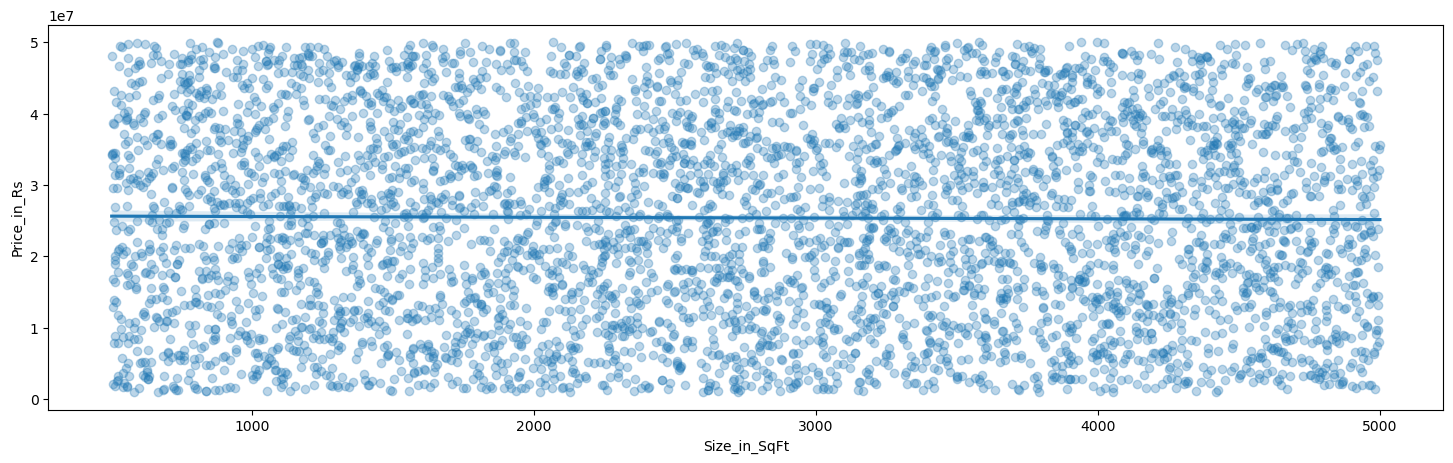

In [35]:
sns.regplot(
    data=df.sample(5000),  # sample for performance
    x="Size_in_SqFt",
    y="Price_in_Rs",
    scatter_kws={"alpha":0.3}
)

Price distribution is nearly identical across all size buckets, with ~60% of properties falling in the 2–5Cr range regardless of size.
This shows little to no relationship between size and total price, meaning other factors (or synthetic structure) are dominating pricing

## 5.	Are there any outliers in price per sq ft or property size?

<Axes: xlabel='Price_per_SqFt'>

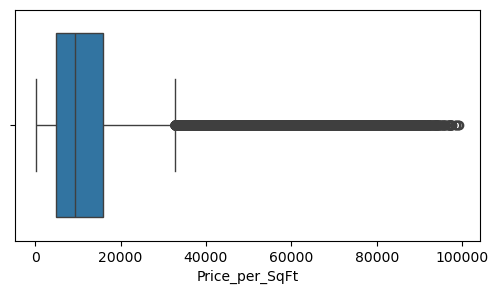

In [36]:
plt.figure(figsize = (6,3))
sns.boxplot(x=df['Price_per_SqFt'])

<Axes: xlabel='Size_in_SqFt'>

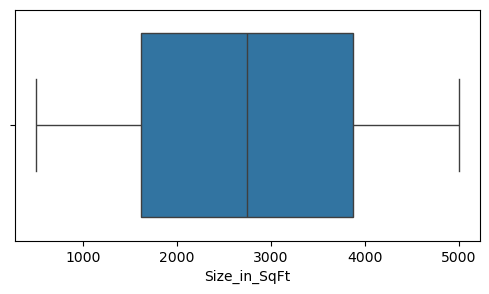

In [37]:
plt.figure(figsize = (6,3))
sns.boxplot(x=df['Size_in_SqFt'])

## 6–10: Location-based Analysis
### 6.	What is the average price per sq ft by state?

<function matplotlib.pyplot.show(close=None, block=None)>

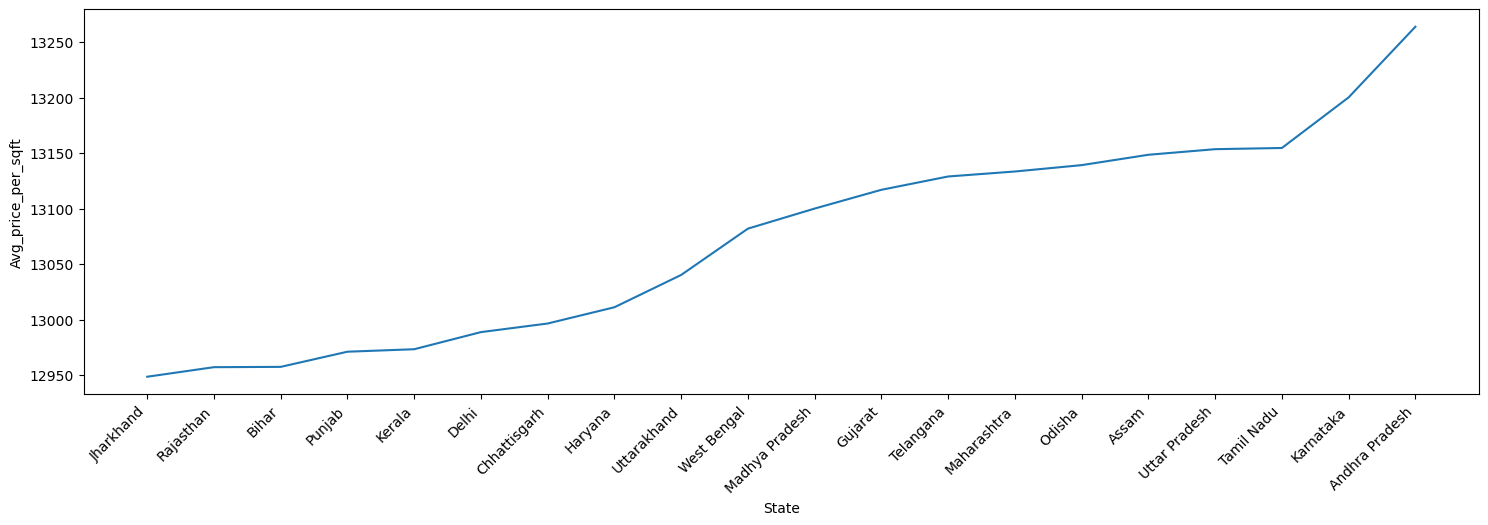

In [38]:
state_price = (df.groupby('State').agg(Avg_price_per_sqft = ('Price_per_SqFt','mean'))).sort_values(by = 'Avg_price_per_sqft')
sns.lineplot(x=state_price.index,y = state_price["Avg_price_per_sqft"])
plt.xticks(rotation=45, ha='right')
plt.show

## 7.	What is the average property price by city?

<function matplotlib.pyplot.show(close=None, block=None)>

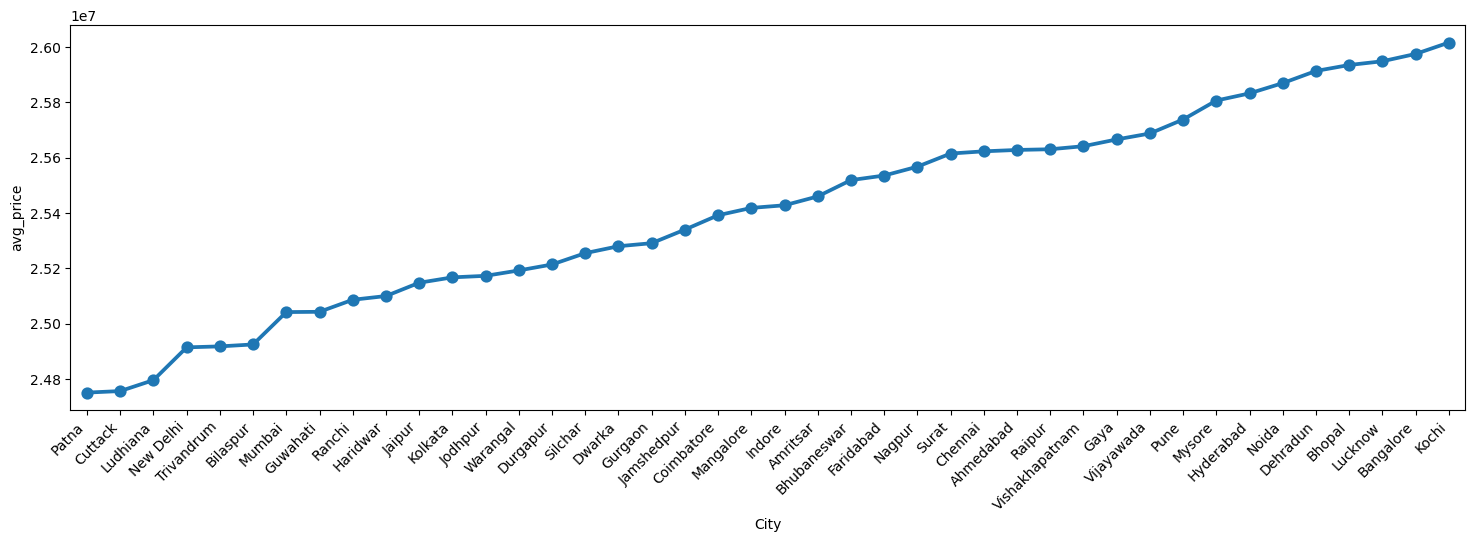

In [39]:
city_price = (df.groupby('City').agg(avg_price = ('Price_in_Rs','median'))).sort_values(by = 'avg_price')
sns.pointplot(data=city_price,x='City',y='avg_price')
plt.xticks(rotation=45, ha='right')
plt.show

## 8.	What is the median age of properties by locality?

In [40]:
locality = (df.groupby('Locality').agg(median_age = ('Age_of_Property','median'))).sort_values(by = 'median_age')
locality

,median_age
Locality,
Locality_186,17.0
Locality_443,17.0
Locality_181,17.5
Locality_13,18.0
Locality_348,18.0
...,...
Locality_72,22.0
Locality_300,22.0
Locality_302,22.0


## 9.	How is BHK distributed across cities?

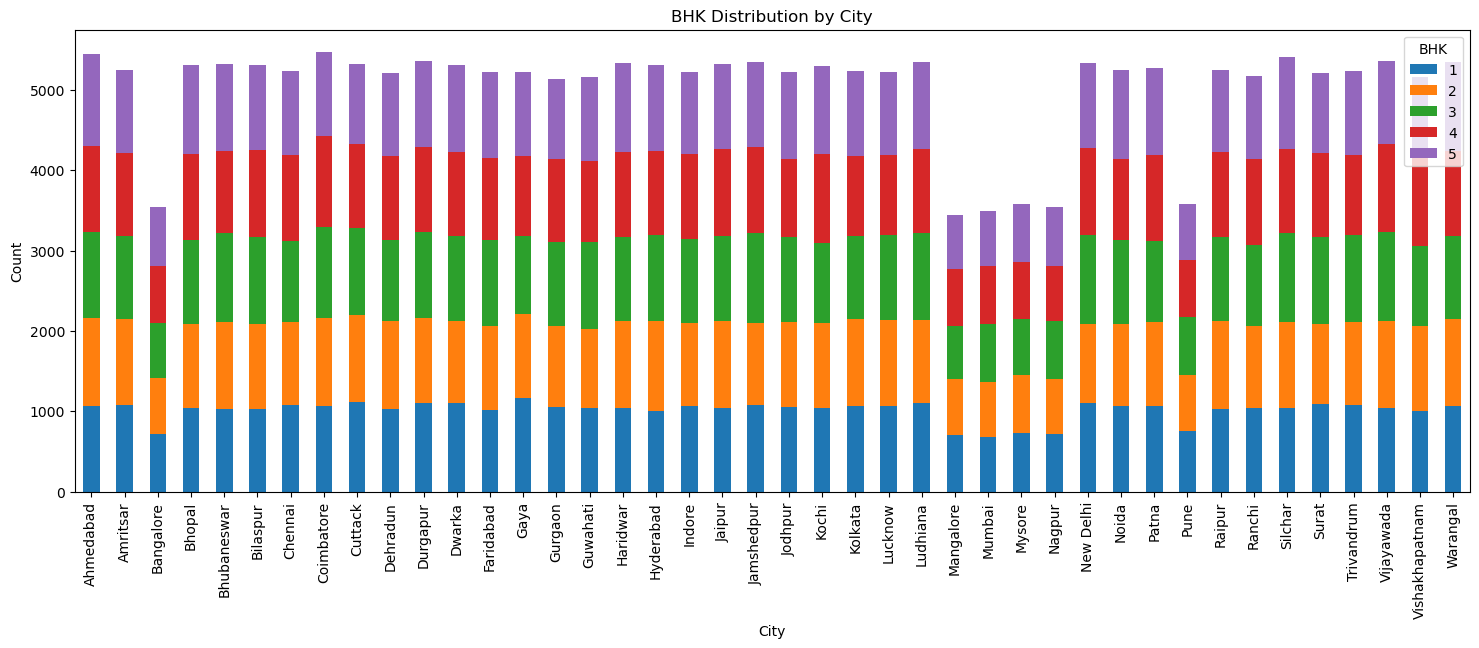

In [41]:
bhk_dist = df.groupby(['City', 'BHK']).size().unstack(fill_value=0)
bhk_dist.plot(kind='bar', stacked=True, figsize=(18,6))

plt.title("BHK Distribution by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()

## 10.	What are the price trends for the top 5 most expensive localities?

<Axes: xlabel='Year_Built', ylabel='Price_in_Rs'>

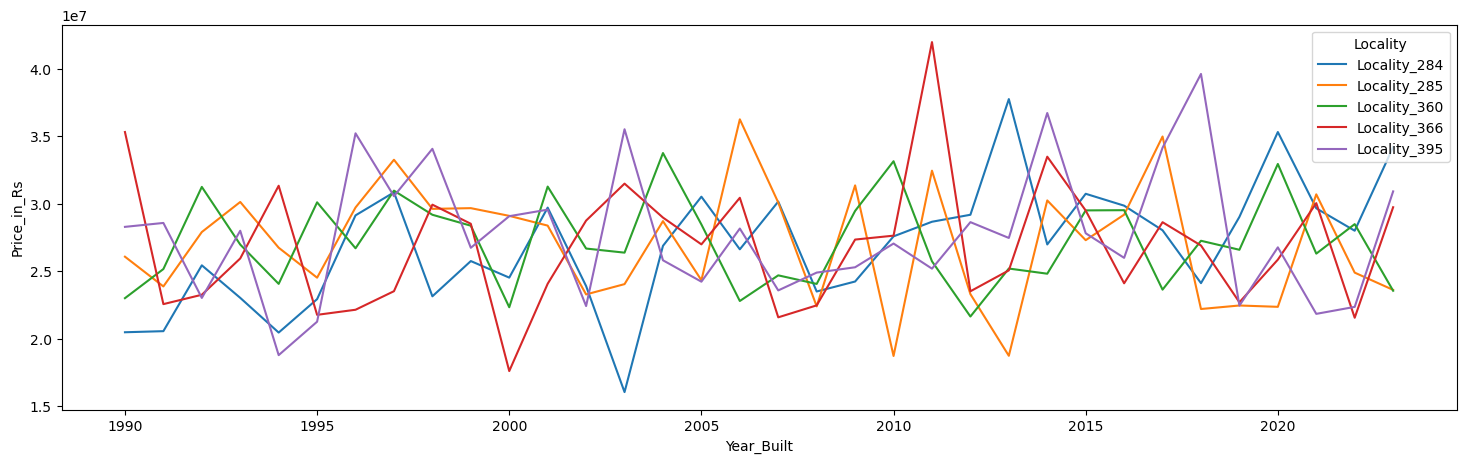

In [42]:
price_trends = ((df.groupby('Locality').agg(price = ('Price_in_Rs','mean'))).sort_values(by = 'price',ascending = False)).head(5)
top5 = price_trends.index
df_top5 = df[df['Locality'].isin(top5)]
trend = df_top5.groupby(['Year_Built', 'Locality'])['Price_in_Rs'].mean().reset_index()
sns.lineplot(data=trend, x='Year_Built', y='Price_in_Rs', hue='Locality')

## 11–15: Feature Relationship & Correlation
### 11.	How are numeric features correlated with each other?

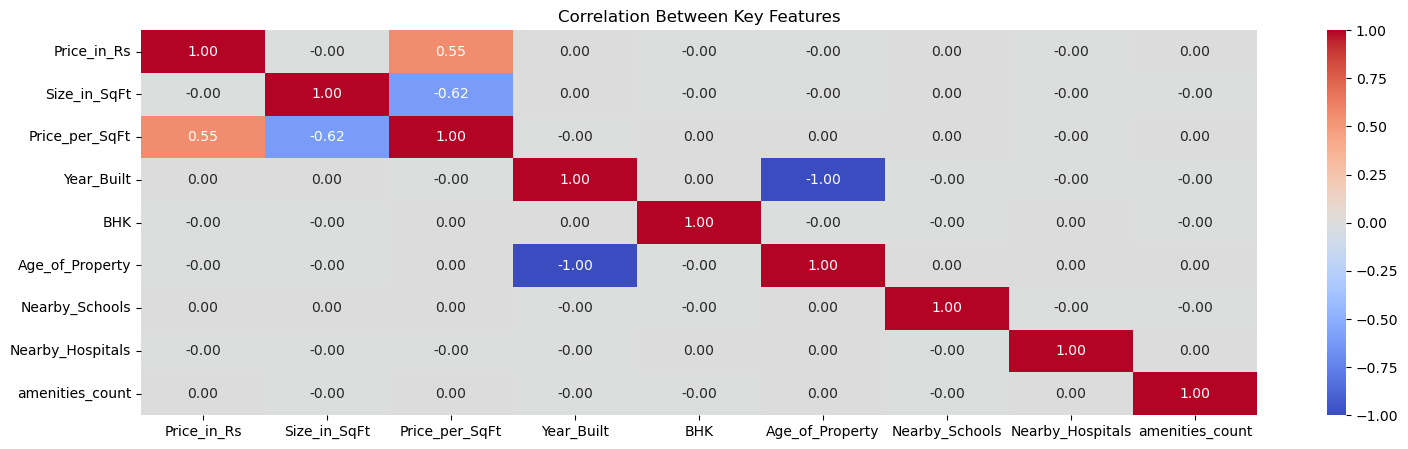

In [43]:
cols = ["Price_in_Rs", "Size_in_SqFt", "Price_per_SqFt", "Year_Built","BHK","Age_of_Property","Nearby_Schools","Nearby_Hospitals","amenities_count"]
corr = df[cols].corr()
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Key Features")
plt.show()

## 12.	How do nearby schools relate to price per sq ft?
## 13.	How do nearby hospitals relate to price per sq ft?

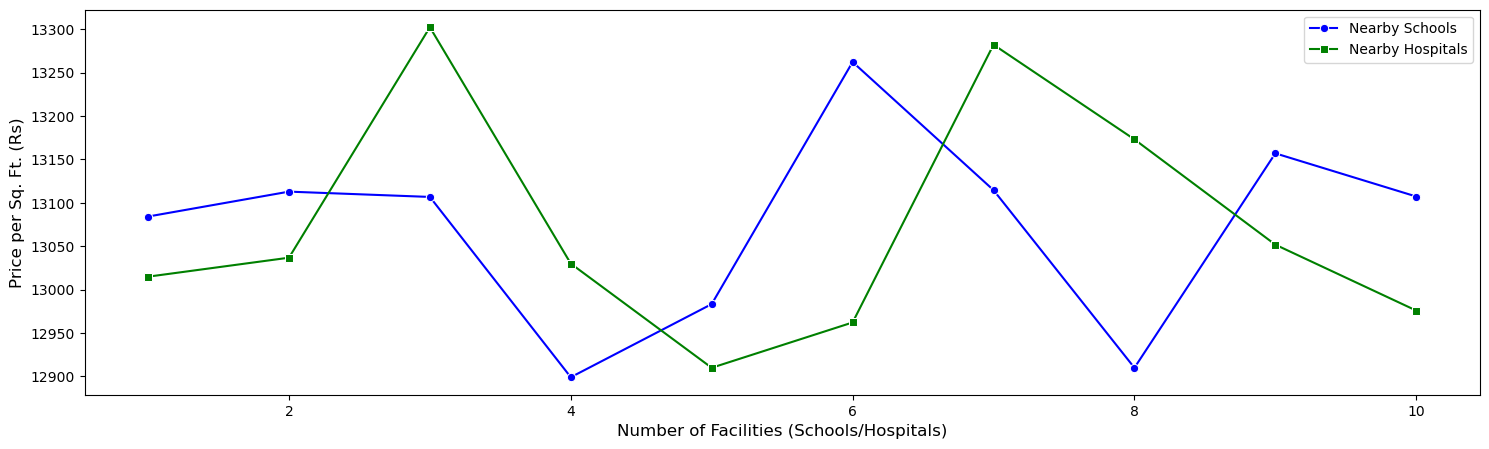

In [44]:
# Plotting School impact
sns.lineplot(data=df, x='Nearby_Schools', y='Price_per_SqFt', 
             label='Nearby Schools', marker='o', color='blue', errorbar=None)

# Plotting Hospital impact
sns.lineplot(data=df, x='Nearby_Hospitals', y='Price_per_SqFt', 
             label='Nearby Hospitals', marker='s', color='green', errorbar=None)

# Customizing the chart
plt.xlabel('Number of Facilities (Schools/Hospitals)', fontsize=12)
plt.ylabel('Price per Sq. Ft. (Rs)', fontsize=12)


plt.show()

## 14.	How does price vary by furnished status?

<Axes: xlabel='Year_Built', ylabel='Price_in_Rs'>

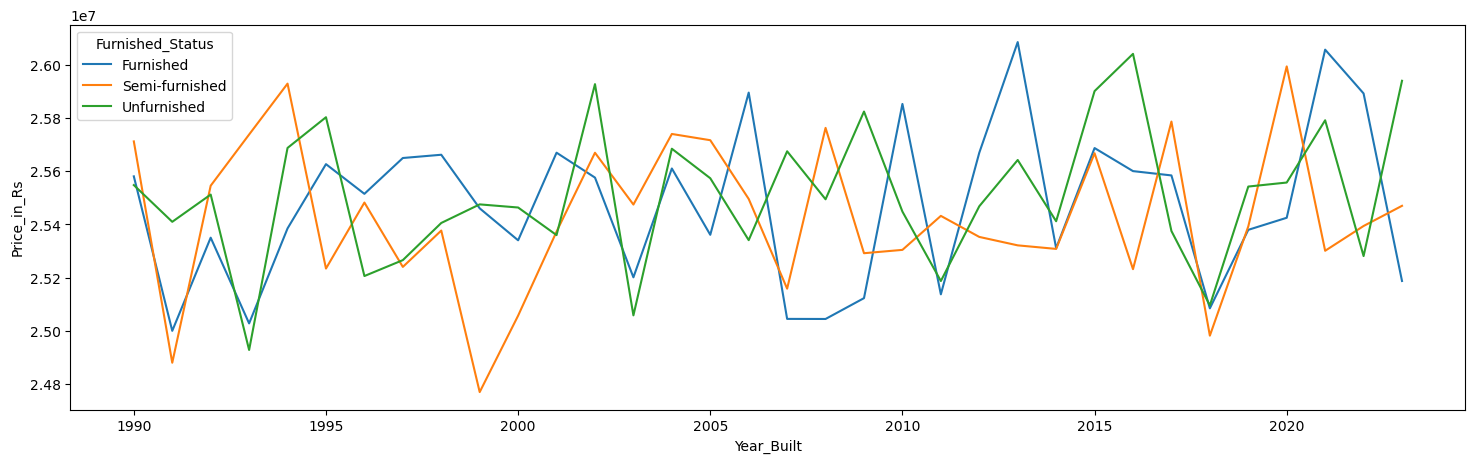

In [45]:
sns.lineplot(data = df, x = 'Year_Built',y = 'Price_in_Rs',hue = 'Furnished_Status',errorbar=None)


## 15. How does price per sq ft vary by property facing direction?

<Axes: xlabel='Year_Built', ylabel='Price_per_SqFt'>

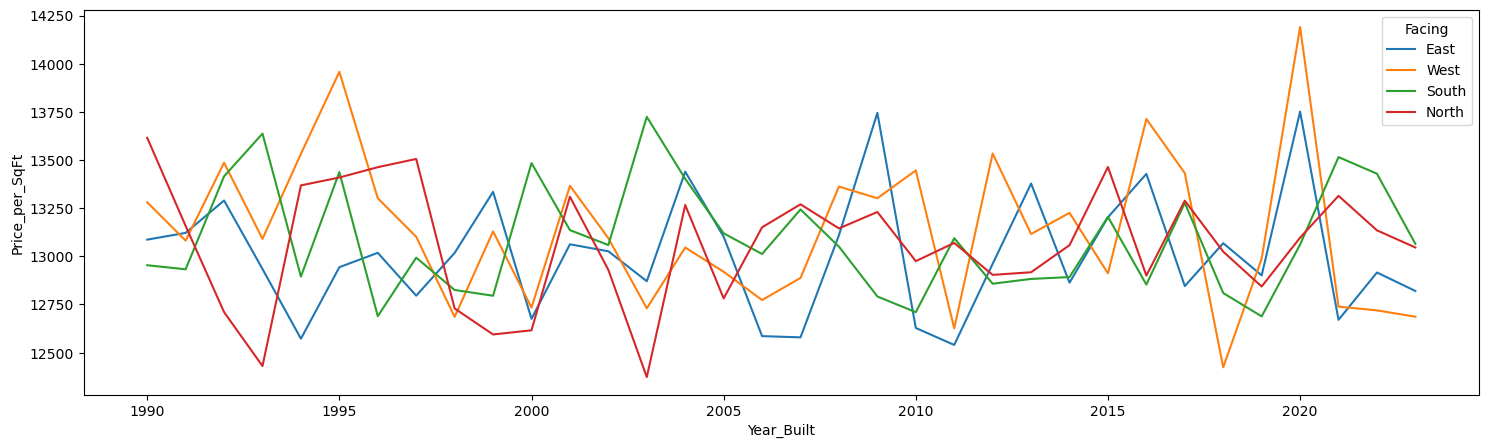

In [46]:
sns.lineplot(data = df, x = 'Year_Built',y = 'Price_per_SqFt',hue = 'Facing',errorbar=None)

<Axes: xlabel='Facing', ylabel='Price_per_SqFt'>

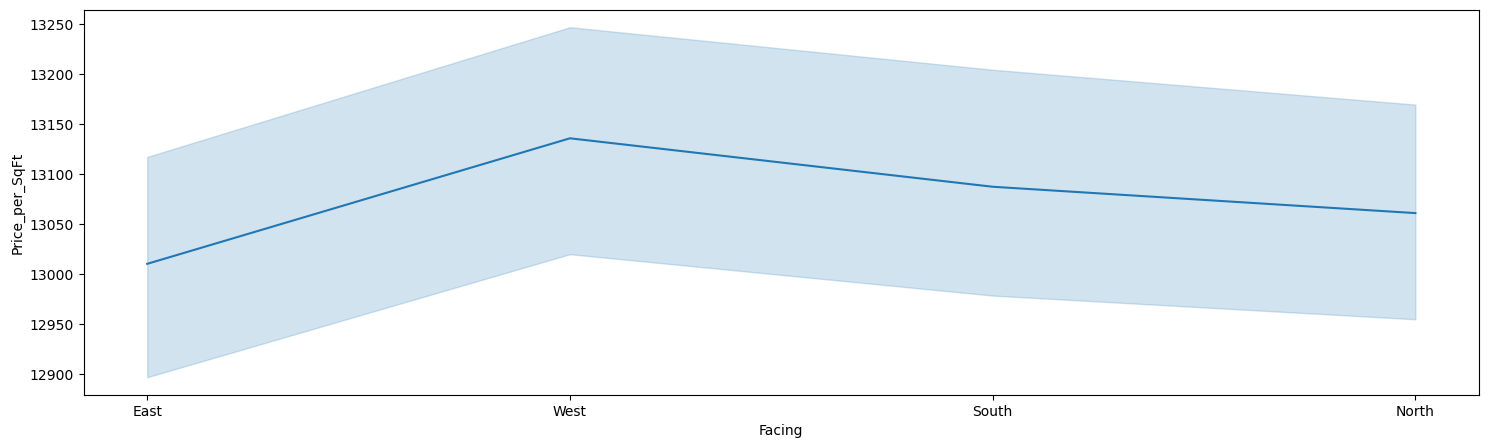

In [47]:
sns.lineplot(data=df, x="Facing", y="Price_per_SqFt")

## 16–20: Investment / Amenities / Ownership Analysis
### 16.	How many properties belong to each owner type?

In [48]:
df['Owner_Type'].value_counts()

Owner_Type
Broker     70607
Owner      70383
Builder    70371
Name: count, dtype: int64

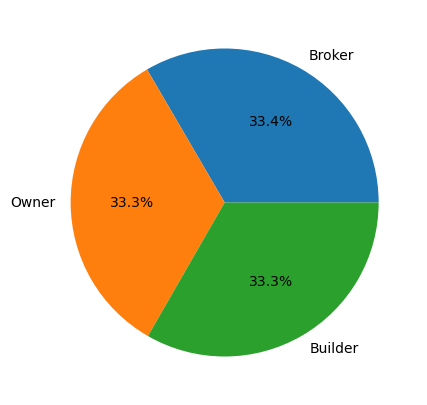

In [49]:
counts = df['Owner_Type'].value_counts()
plt.pie(counts,labels = counts.index,autopct = "%1.1f%%")
plt.show()

## 17.	How many properties are available under each availability status?

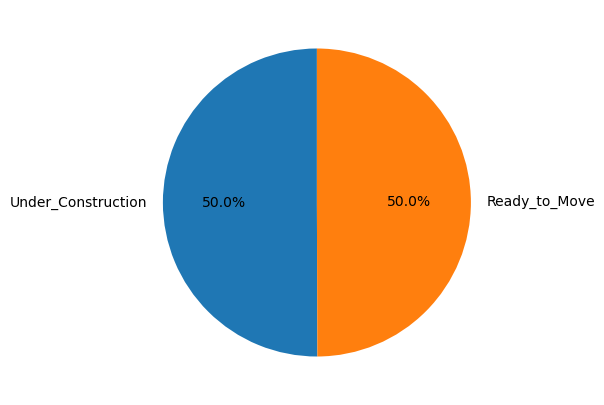

In [50]:
counts = df["Availability_Status"].value_counts()
plt.pie(counts,labels=counts.index,autopct="%1.1f%%",startangle=90)
plt.show()

In [51]:
df.groupby("Availability_Status")['Price_in_Rs'].mean()

Availability_Status
Ready_to_Move         2.550627e+07
Under_Construction    2.543575e+07
Name: Price_in_Rs, dtype: float64

## 18.	Does parking space affect property price?

<Axes: xlabel='Parking_Space', ylabel='Price_in_Rs'>

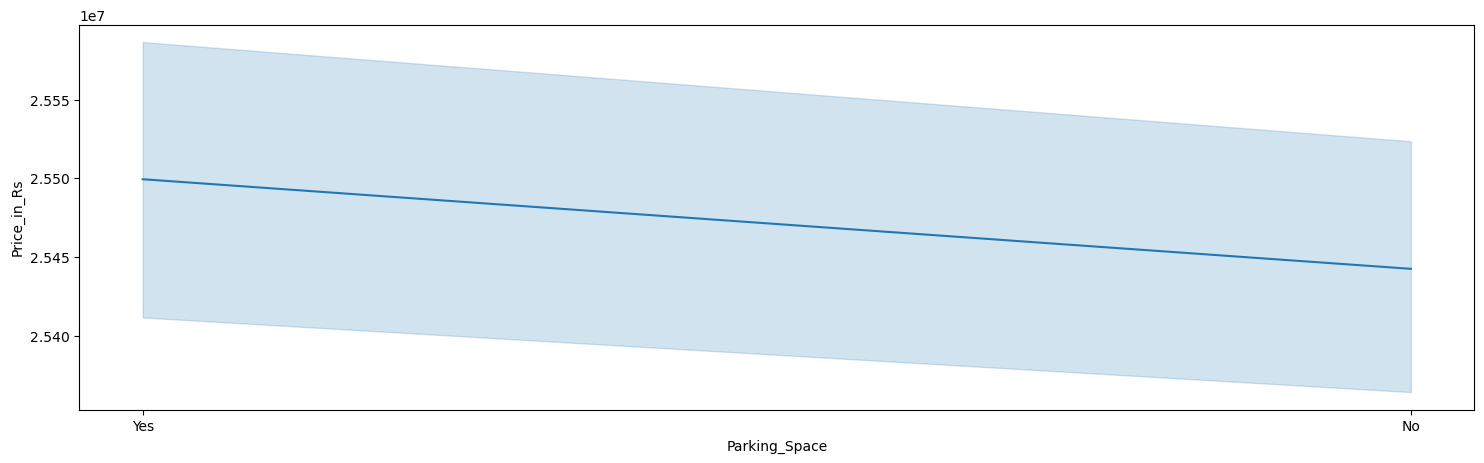

In [52]:
sns.lineplot(data = df, x = 'Parking_Space',y = 'Price_in_Rs')

In [53]:
df.groupby("Parking_Space").agg(price = ('Price_in_Rs','mean'))

,price
Parking_Space,
No,2.544266e+07
Yes,2.549948e+07


## 19.	How do amenities affect price per sq ft?

<Axes: xlabel='amenities_count', ylabel='Price_per_SqFt'>

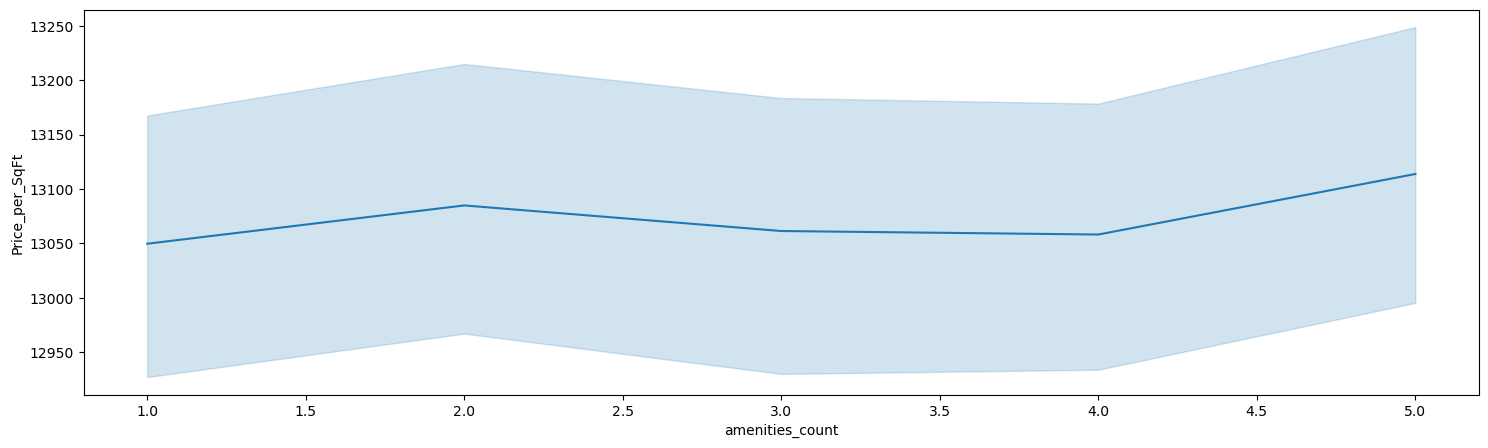

In [54]:
sns.lineplot(data=df, x="amenities_count", y="Price_per_SqFt")

In [55]:
df.groupby("amenities_count")["Price_per_SqFt"].mean()

amenities_count
1    13049.687413
2    13084.859790
3    13061.366000
4    13058.150782
5    13113.737057
Name: Price_per_SqFt, dtype: float64

## 20.	How does public transport accessibility relate to price per sq ft or investment potential?

In [56]:
df.groupby('Public_Transport_Accessibility')['Price_per_SqFt'].mean()

Public_Transport_Accessibility
High      13047.183432
Low       13089.369490
Medium    13084.187762
Name: Price_per_SqFt, dtype: float64

<Axes: xlabel='Year_Built', ylabel='Price_per_SqFt'>

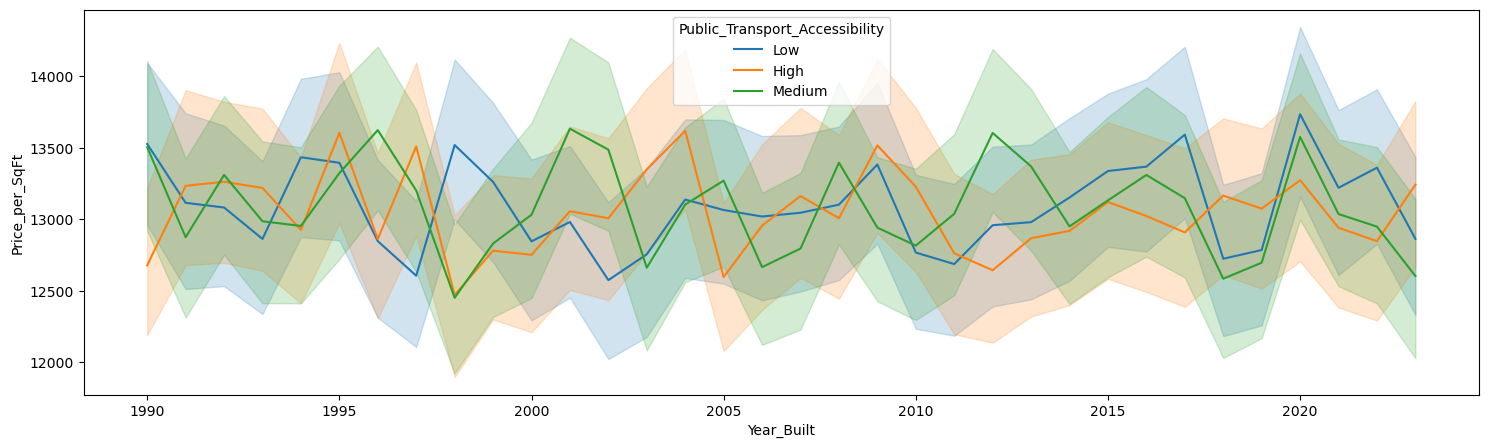

In [57]:
sns.lineplot(data = df, x = 'Year_Built',y = 'Price_per_SqFt',hue = 'Public_Transport_Accessibility')

<Axes: xlabel='Public_Transport_Accessibility', ylabel='Price_per_SqFt'>

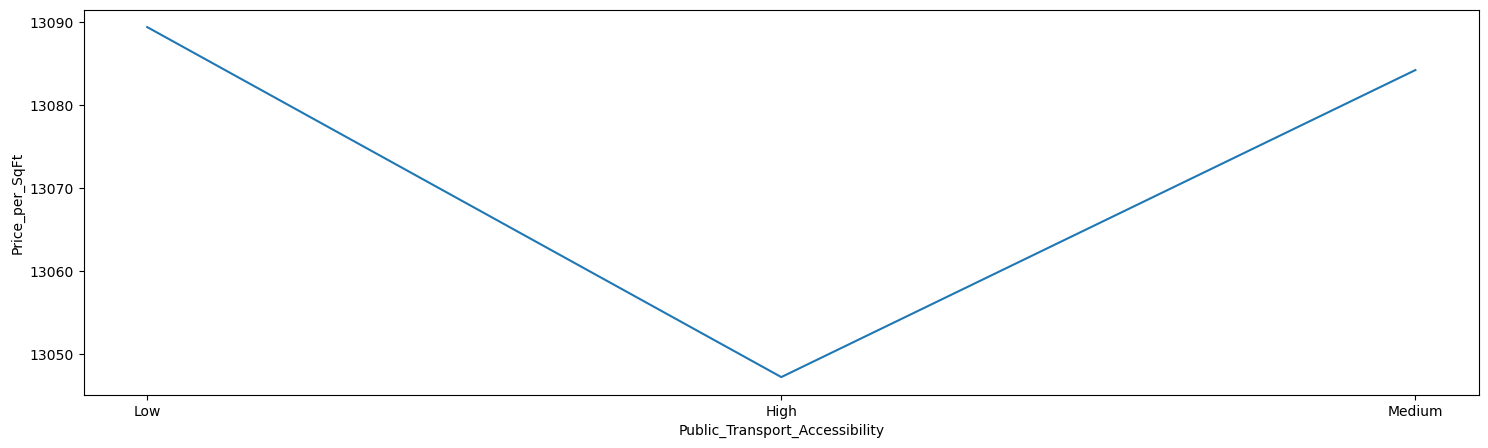

In [58]:
sns.lineplot(data=df, x="Public_Transport_Accessibility", y="Price_per_SqFt",errorbar = None)

In [59]:
df.groupby('Public_Transport_Accessibility')[['Price_in_Rs','Price_per_SqFt']].mean()

,Price_in_Rs,Price_per_SqFt
Public_Transport_Accessibility,,
High,2.549250e+07,13047.183432
Low,2.547954e+07,13089.369490
Medium,2.544064e+07,13084.187762
